<a href="https://colab.research.google.com/github/shreyasacharya1/ML/blob/main/1BM23CS320_lab3_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/HR_comma_sep - HR_comma_sep.csv')

# Display the first 5 rows
print("First 5 rows of the DataFrame:")
print(df.head())

# Display concise summary information
print("\nSummary information of the DataFrame:")
df.info()

First 5 rows of the DataFrame:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   sala

In [ ]:
df_left = df[df['left'] == 1]
df_stayed = df[df['left'] == 0]

print("First 5 rows of employees who LEFT:")
print(df_left.head())

print("\nFirst 5 rows of employees who STAYED:")
print(df_stayed.head())

First 5 rows of employees who LEFT:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

  

In [ ]:
numerical_cols = df.select_dtypes(include=['number']).columns.drop('left')

print("\nDescriptive statistics for employees who LEFT (numerical features):")
print(df_left[numerical_cols].describe())

print("\nDescriptive statistics for employees who STAYED (numerical features):")
print(df_stayed[numerical_cols].describe())


Descriptive statistics for employees who LEFT (numerical features):
       satisfaction_level  last_evaluation  number_project  \
count         3571.000000      3571.000000     3571.000000   
mean             0.440098         0.718113        3.855503   
std              0.263933         0.197673        1.818165   
min              0.090000         0.450000        2.000000   
25%              0.130000         0.520000        2.000000   
50%              0.410000         0.790000        4.000000   
75%              0.730000         0.900000        6.000000   
max              0.920000         1.000000        7.000000   

       average_montly_hours  time_spend_company  Work_accident  \
count           3571.000000         3571.000000    3571.000000   
mean             207.419210            3.876505       0.047326   
std               61.202825            0.977698       0.212364   
min              126.000000            2.000000       0.000000   
25%              146.000000            3.0

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

print("\nPercentage of employees who LEFT within each category:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    # Calculate the total count for each category
    total_counts = df[col].value_counts()
    # Calculate the count of employees who left for each category
    left_counts = df_left[col].value_counts()

    # Calculate the percentage of employees who left per category
    # Handle cases where a category might not have any 'left' employees to avoid division by zero if necessary, though value_counts handles this by default for missing keys.
    percentage_left = (left_counts / total_counts * 100).fillna(0).sort_values(ascending=False)
    print(percentage_left)


Percentage of employees who LEFT within each category:

--- Department ---
Department
hr             29.093369
accounting     26.597132
technical      25.625000
support        24.899058
sales          24.492754
marketing      23.659674
IT             22.249389
product_mng    21.951220
RandD          15.374841
management     14.444444
Name: count, dtype: float64

--- salary ---
salary
low       29.688354
medium    20.431275
high       6.628941
Name: count, dtype: float64


/tmp/ipython-input-261/63476471.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=salary_percentage_left.index, y=salary_percentage_left.values, palette='viridis')


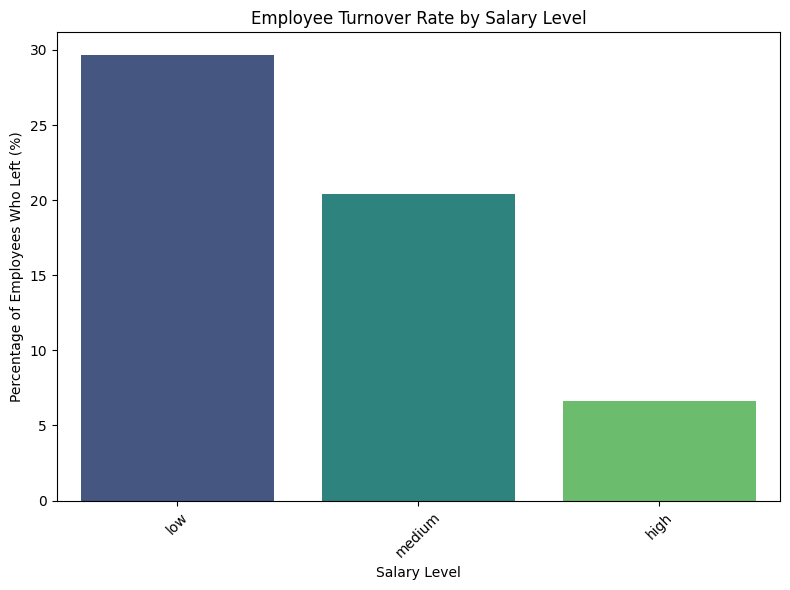

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# The 'percentage_left' Series from the previous step already contains the salary data
# No need to re-index, as its index labels are 'low', 'medium', 'high'.
salary_percentage_left = percentage_left

plt.figure(figsize=(8, 6))
sns.barplot(x=salary_percentage_left.index, y=salary_percentage_left.values, palette='viridis')
plt.xlabel('Salary Level')
plt.ylabel('Percentage of Employees Who Left (%)')
plt.title('Employee Turnover Rate by Salary Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

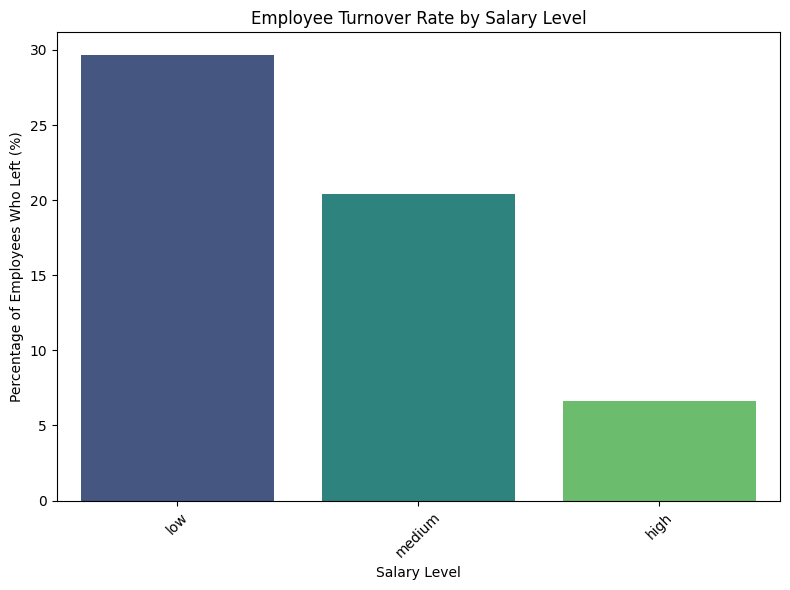

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# The 'percentage_left' Series from the previous step already contains the salary data
# No need to re-index, as its index labels are 'low', 'medium', 'high'.
salary_percentage_left = percentage_left

plt.figure(figsize=(8, 6))
sns.barplot(x=salary_percentage_left.index, y=salary_percentage_left.values, hue=salary_percentage_left.index, palette='viridis', legend=False)
plt.xlabel('Salary Level')
plt.ylabel('Percentage of Employees Who Left (%)')
plt.title('Employee Turnover Rate by Salary Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

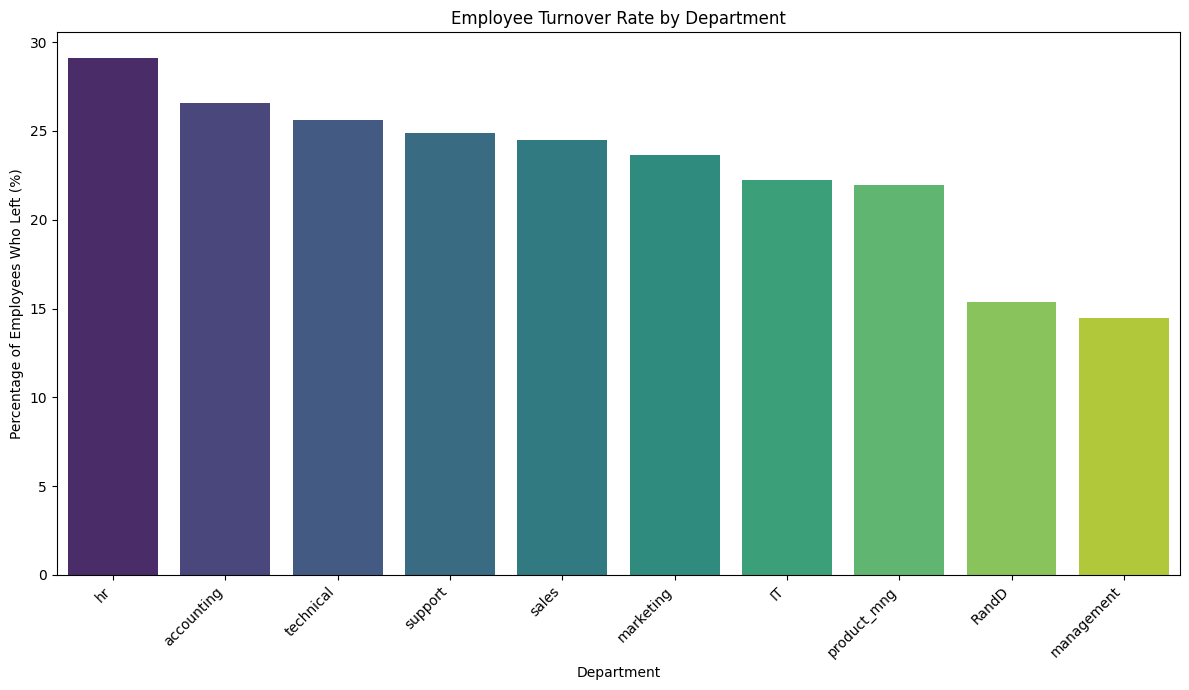

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the total count of employees for each department
total_counts_department = df['Department'].value_counts()

# 2. Calculate the count of employees who left for each department
left_counts_department = df_left['Department'].value_counts()

# 3. Compute the percentage of employees who left per department
percentage_left_department = (left_counts_department / total_counts_department * 100).fillna(0).sort_values(ascending=False)

# 4. Create a bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x=percentage_left_department.index, y=percentage_left_department.values, palette='viridis', hue=percentage_left_department.index, legend=False)

# 5. Label the x-axis and y-axis
plt.xlabel('Department')
plt.ylabel('Percentage of Employees Who Left (%)')

# 6. Add a title to the plot
plt.title('Employee Turnover Rate by Department')

# 7. Rotate the x-axis labels by 45 degrees
plt.xticks(rotation=45, ha='right') # ha='right' aligns labels nicely after rotation

plt.tight_layout() # Adjust layout to prevent labels from overlapping

# 8. Display the plot
plt.show()

In [ ]:
import pandas as pd

# 1. Identify the influential features
features = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours',
            'time_spend_company', 'Work_accident', 'promotion_last_5years', 'Department', 'salary']
target = 'left'

# 2. Create X and y
X = df[features]
y = df[target]

# 3. Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=['Department', 'salary'], drop_first=True)

print("First 5 rows of feature DataFrame (X) after one-hot encoding:")
print(X.head())

First 5 rows of feature DataFrame (X) after one-hot encoding:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  promotion_last_5years  Department_RandD  \
0                   3              0                      0             False   
1                   6              0                      0             False   
2                   4              0                      0             False   
3                   5              0                      0             False   
4                   3              0                

In [ ]:
from sklearn.model_selection import train_test_split

# 4. Split the encoded features X and target y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (10499, 18)
Shape of X_test: (4500, 18)
Shape of y_train: (10499,)
Shape of y_test: (4500,)


In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Instantiate a LogisticRegression model
# Set solver='liblinear' for reproducibility and to handle potential convergence warnings
# Set random_state=42 for reproducibility
model = LogisticRegression(solver='liblinear', random_state=42)

# 2. Train the model using the fit() method with X_train and y_train
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score

# 1. Use the trained logistic regression model to make predictions on the X_test dataset
y_pred = model.predict(X_test)

# 2. Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# 3. Print the calculated accuracy score
print(f"Model Accuracy on the test set: {accuracy:.4f}")

Model Accuracy on the test set: 0.7831


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Define the features (X) by selecting all columns from the DataFrame df
#    except 'animal_name', 'class_type', and 'class_name'.
X = df.drop(columns=['animal_name', 'class_type', 'class_name'])

# 2. Define the target variable (y) as the 'class_type' column from the DataFrame df.
y = df['class_type']

# 3. Split the features (X) and target (y) into training and testing sets
#    using a 70/30 ratio, setting random_state to 42 for reproducibility.
#    Assign the results to X_train, X_test, y_train, and y_test respectively.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Print the shapes of the resulting training and testing sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (70, 16)
Shape of X_test: (31, 16)
Shape of y_train: (70,)
Shape of y_test: (31,)


In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Instantiate a LogisticRegression model
# Specify multi_class='multinomial' since the target variable 'class_type' has multiple classes
# Use solver='lbfgs' which is a good default for multinomial logistic regression
# Set random_state=42 for reproducibility
model_zoo = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)

# 2. Train the model using the fit() method with X_train and y_train
model_zoo.fit(X_train, y_train)

print("Logistic Regression model for Zoo dataset trained successfully.")

Logistic Regression model for Zoo dataset trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Make predictions on the test set using the trained model
y_pred_zoo = model_zoo.predict(X_test)

# 2. Evaluate the model's performance
print("\nClassification Report for Zoo Dataset:")
print(classification_report(y_test, y_pred_zoo))

accuracy_zoo = accuracy_score(y_test, y_pred_zoo)
print(f"\nAccuracy Score for Zoo Dataset: {accuracy_zoo:.4f}")


Classification Report for Zoo Dataset:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         2
           6       0.83      1.00      0.91         5
           7       1.00      0.67      0.80         3

    accuracy                           0.94        31
   macro avg       0.79      0.81      0.79        31
weighted avg       0.92      0.94      0.92        31


Accuracy Score for Zoo Dataset: 0.9355


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


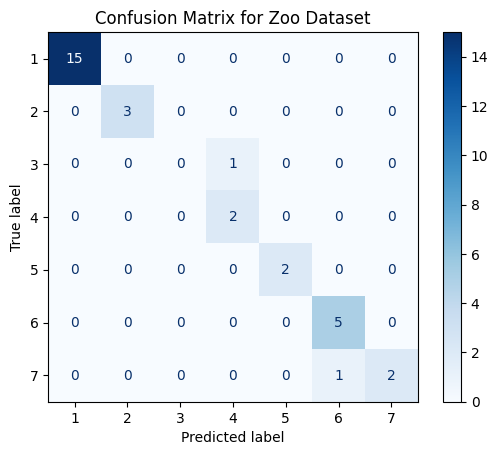

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix using y_test and y_pred_zoo for the Zoo dataset
cm = confusion_matrix(y_test, y_pred_zoo)

# Display the confusion matrix using the model_zoo's classes for labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_zoo.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Zoo Dataset')
plt.show()

In [ ]:
# Manual Calculation of Accuracy
correct_predictions = 0
total_predictions = len(y_test)

for i in range(total_predictions):
    if y_test.iloc[i] == y_pred[i]:
        correct_predictions += 1

manual_accuracy = correct_predictions / total_predictions
print(f"Manual Accuracy on the test set: {manual_accuracy:.4f}")

# Manual Calculation of Binary Confusion Matrix
tp = 0  # True Positives: Actual 1, Predicted 1
tn = 0  # True Negatives: Actual 0, Predicted 0
fp = 0  # False Positives: Actual 0, Predicted 1
fn = 0  # False Negatives: Actual 1, Predicted 0

for i in range(total_predictions):
    actual = y_test.iloc[i]
    predicted = y_pred[i]

    if actual == 1 and predicted == 1:
        tp += 1
    elif actual == 0 and predicted == 0:
        tn += 1
    elif actual == 0 and predicted == 1:
        fp += 1
    elif actual == 1 and predicted == 0:
        fn += 1

print("\nManual Confusion Matrix:")
print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

Manual Accuracy on the test set: 0.0645

Manual Confusion Matrix:
True Positives (TP): 2
True Negatives (TN): 0
False Positives (FP): 0
False Negatives (FN): 13
